In [15]:
!pip install -r requirements.txt

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [26]:
df = pd.read_csv('data/Obesity Classification.csv')

print("Visualização inicial dos dados:")
display(df.head())

Visualização inicial dos dados:


,ID,Age,Gender,Height,Weight,BMI,Label
0,1,25,Male,175,80,25.300,Normal Weight
1,2,30,Female,160,60,22.500,Normal Weight
2,3,35,Male,180,90,27.300,Overweight
3,4,40,Female,150,50,20.000,Underweight
4,5,45,Male,190,100,31.200,Obese


In [27]:
# A coluna ID não tem poder preditivo e serve apenas como identificador.
df = df.drop(columns=['ID'])

# Verificando se há valores nulos
print("\nValores nulos no dataset:")
print(df.isnull().sum())

# Codificando as variáveis categóricas
le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender']) # Ex: Female=0, Male=1

le_label = LabelEncoder()
df['Label'] = le_label.fit_transform(df['Label'])
print("\nClasses de Obesidade mapeadas para números:")
for num, name in enumerate(le_label.classes_):
    print(f"{num}: {name}")


Valores nulos no dataset:
Age       0
Gender    0
Height    0
Weight    0
BMI       0
Label     0
dtype: int64

Classes de Obesidade mapeadas para números:
0: Normal Weight
1: Obese
2: Overweight
3: Underweight


=== FASE 2: SELEÇÃO DE VARIÁVEIS MULTIMÉTODO ===



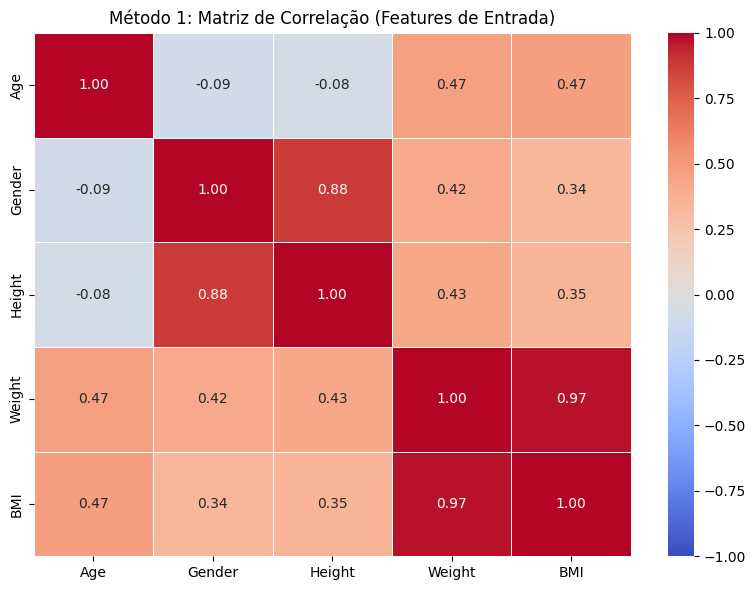

/tmp/ipykernel_17994/688596231.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F-Score', y='Feature', data=anova_scores, palette='viridis')


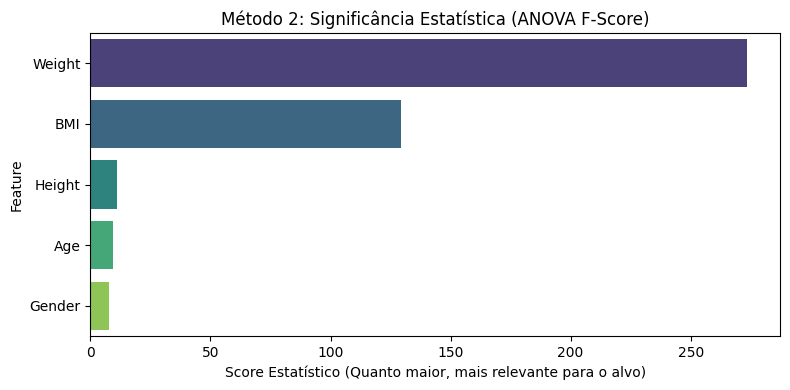

/tmp/ipykernel_17994/688596231.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância (%)', y='Feature', data=importance_df, palette='magma')


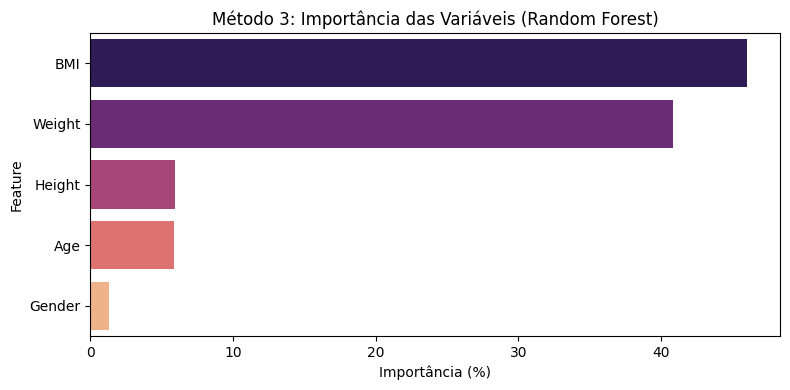

Resumo das Importâncias (Random Forest):


,Feature,Importância (%)
4,BMI,46.046
3,Weight,40.855
2,Height,5.935
0,Age,5.855
1,Gender,1.310



Features selecionadas para o treinamento da Rede Neural MLP:
['Age', 'Gender', 'BMI']


In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif

# Supondo que 'df' já passou pela Fase 1 (ID removido, variáveis codificadas)
# Separando as variáveis de entrada (X) e o alvo (y)
X = df.drop(columns=['Label'])
y = df['Label']

print("=== FASE 2: SELEÇÃO DE VARIÁVEIS MULTIMÉTODO ===\n")

# ---------------------------------------------------------
# Método 1: Matriz de Correlação (Multicolinearidade)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Método 1: Matriz de Correlação (Features de Entrada)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Método 2: Significância Estatística (ANOVA F-value)
# ---------------------------------------------------------
# O teste F avalia se a média de cada feature varia significativamente entre as classes de obesidade
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

anova_scores = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': selector.scores_
}).sort_values(by='F-Score', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='F-Score', y='Feature', data=anova_scores, palette='viridis')
plt.title("Método 2: Significância Estatística (ANOVA F-Score)")
plt.xlabel("Score Estatístico (Quanto maior, mais relevante para o alvo)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Método 3: Feature Importance (Random Forest)
# ---------------------------------------------------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importância (%)': rf_model.feature_importances_ * 100
}).sort_values(by='Importância (%)', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importância (%)', y='Feature', data=importance_df, palette='magma')
plt.title("Método 3: Importância das Variáveis (Random Forest)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# DECISÃO FINAL DE FEATURE SELECTION
# ---------------------------------------------------------
print("Resumo das Importâncias (Random Forest):")
display(importance_df)

# Removendo Weight e Height devido à altíssima redundância com BMI
# e mantendo apenas as features que trazem informações únicas e alto poder preditivo.
X_final = X.drop(columns=['Weight', 'Height'])

print("\nFeatures selecionadas para o treinamento da Rede Neural MLP:")
print(list(X_final.columns))

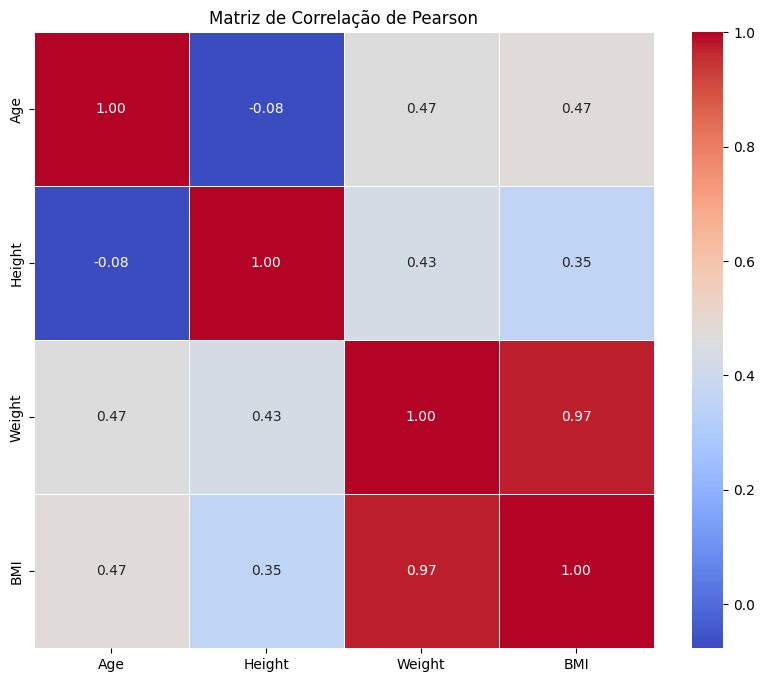

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carregar seu dataset
df = pd.read_csv('data/Obesity Classification.csv') 

# 2. Selecionar apenas as colunas numéricas que importam para a análise
# Incluímos Peso e Altura para mostrar ao professor que elas têm alta correlação com o IMC
cols_analise = ['Age', 'Height', 'Weight', 'BMI']
corr_matrix = df[cols_analise].corr()

# 3. Gerar o gráfico (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação de Pearson')

# 4. Salvar a imagem para usar no LaTeX
plt.savefig('matriz_correlacao.png', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import wandb
import pandas as pd
import numpy as np

# 1. Preparação Final dos Dados
# Assumindo que X_final tem apenas: ['Age', 'Gender', 'BMI'] e y é o nosso Label
# Vamos dividir os dados em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

# Normalização (Z-score)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Definição do Dataset para o PyTorch
class ObesityDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels.values, dtype=torch.long) # Labels devem ser 'long' (inteiros)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

train_dataset = ObesityDataset(X_train_scaled, y_train)
test_dataset = ObesityDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 3. Definição da Arquitetura da Rede Neural (MLP)
class ObesityMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, output_dim):
        super(ObesityMLP, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim1)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.layer3 = nn.Linear(hidden_dim2, output_dim)
        
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x) # Não aplicamos Softmax aqui pois a Loss Function CrossEntropyLoss já o faz internamente
        return x

# Fazendo o login automático com a sua chave 
# (Lembre-se de apagar essa chave do código antes de mandar pro GitHub!)
wandb.login(key="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")

# Iniciando o rastreamento do projeto com um NOVO NOME
wandb.init(
    project="Avaliação1", # <--- Altere apenas esta linha!
    name="experimento-01-baseline",       # (Opcional) Nome específico dessa rodada de testes
    config={
        "learning_rate": 0.001,
        "epochs": 50,
        "batch_size": 16,
        "hidden_layer_1": 16,
        "hidden_layer_2": 8,
        "optimizer": "Adam",
        "loss_function": "CrossEntropyLoss"
    }
)

config = wandb.config

config = wandb.config

# Instanciando o modelo, função de perda e otimizador
model = ObesityMLP(input_dim=X_train_scaled.shape[1], 
                   hidden_dim1=config.hidden_layer_1, 
                   hidden_dim2=config.hidden_layer_2, 
                   output_dim=4) # 4 classes de obesidade

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)

# 5. Ciclo de Treinamento (Training Loop)
print("A iniciar o treinamento...")
for epoch in range(config.epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        optimizer.zero_grad() # Zerar os gradientes
        
        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, labels) # Cálculo do erro
        loss.backward() # Backpropagation
        optimizer.step() # Atualização dos pesos
        
        running_loss += loss.item()
        
        # Calculando a precisão do batch
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    
    # Validação (Teste)
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    val_epoch_loss = val_loss / len(test_loader)
    val_epoch_acc = 100 * val_correct / val_total
    
    # 6. Registando métricas no W&B (Obrigatório para a avaliação)
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": epoch_loss,
        "train_accuracy": epoch_acc,
        "val_loss": val_epoch_loss,
        "val_accuracy": val_epoch_acc
    })
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{config.epochs}] - Train Loss: {epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.2f}%")

print("Treinamento concluído!")

# 7. Salvando o modelo (Artifact Versioning no W&B)
torch.save(model.state_dict(), "mlp_model.pth")
artifact = wandb.Artifact('modelo-obesidade', type='model')
artifact.add_file('mlp_model.pth')
wandb.log_artifact(artifact)

wandb.finish()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/felipe/.netrc


A iniciar o treinamento...
Epoch [10/50] - Train Loss: 1.3416, Val Loss: 1.3313, Val Acc: 50.00%
Epoch [20/50] - Train Loss: 1.2496, Val Loss: 1.2293, Val Acc: 45.45%
Epoch [30/50] - Train Loss: 1.0481, Val Loss: 1.0175, Val Acc: 50.00%
Epoch [40/50] - Train Loss: 0.9083, Val Loss: 0.8665, Val Acc: 54.55%
Epoch [50/50] - Train Loss: 0.8056, Val Loss: 0.7629, Val Acc: 68.18%
Treinamento concluído!


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train_accuracy,▁▁▂▄▆▇▇▇▇▇▆▆▆▆▆▆▆▆▆▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇██▇██
train_loss,█████▇▇▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁
val_accuracy,▁▂▄▄▅▆▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▆▆▆▇▇▇▇███
val_loss,███████▇▇▇▇▇▇▇▇▆▆▆▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁
epoch,50
train_accuracy,58.13953
train_loss,0.80564
val_accuracy,68.18182
val_loss,0.76289
